In [ ]:
"""
UTKFace 데이터를 필요로 합니다.'
https://www.kaggle.com/datasets/jangedoo/utkface-new 에서 데이터를 구할수있습니다.
"""

In [1]:
!pip install pandas
!pip install scikit-learn
!pip install matplotlib
!pip install pillow

In [6]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt


In [4]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Activation
from tensorflow.keras.layers import MaxPool2D
from tensorflow.keras.layers import SpatialDropout2D
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.initializers import HeNormal
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import ModelCheckpoint

In [7]:
img_dir = r'D:\03.cnn-20250714T013117Z-1-001\03.cnn\UTKFace'
file_names=[f for f in os.listdir(img_dir)if f.endswith('.jpg')]
file_names

['100_0_0_20170112213500903.jpg.chip.jpg',
 '100_0_0_20170112215240346.jpg.chip.jpg',
 '100_1_0_20170110183726390.jpg.chip.jpg',
 '100_1_0_20170112213001988.jpg.chip.jpg',
 '100_1_0_20170112213303693.jpg.chip.jpg',
 '100_1_0_20170112215032192.jpg.chip.jpg',
 '100_1_0_20170117195420803.jpg.chip.jpg',
 '100_1_0_20170119212053665.jpg.chip.jpg',
 '100_1_2_20170105174847679.jpg.chip.jpg',
 '100_1_2_20170112213615815.jpg.chip.jpg',
 '100_1_2_20170112222336458.jpg.chip.jpg',
 '101_0_0_20170112213500903.jpg.chip.jpg',
 '101_1_2_20170105174739309.jpg.chip.jpg',
 '103_0_2_20170112213001988.jpg.chip.jpg',
 '105_0_0_20170112213001988.jpg.chip.jpg',
 '105_1_0_20170112213001988.jpg.chip.jpg',
 '105_1_0_20170112213021902.jpg.chip.jpg',
 '105_1_0_20170112213507183.jpg.chip.jpg',
 '105_1_1_20170112213303693.jpg.chip.jpg',
 '10_0_0_20161220222308131.jpg.chip.jpg',
 '10_0_0_20170103200329407.jpg.chip.jpg',
 '10_0_0_20170103200522151.jpg.chip.jpg',
 '10_0_0_20170103233459275.jpg.chip.jpg',
 '10_0_0_201701

In [9]:
age_list=[int(f.split('_')[0])for f in file_names]
age_list

[100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 100,
 101,
 101,
 103,
 105,
 105,
 105,
 105,
 105,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 110,
 110,
 110,
 110,
 110,
 111,
 115,
 115,
 115,
 116,
 116,
 116,
 116,
 11,
 11,
 11,
 11,
 11,
 11

In [11]:
data = pd.DataFrame({
    'filename':file_names,
    'age':age_list
})
data

,filename,age
0,100_0_0_20170112213500903.jpg.chip.jpg,100
1,100_0_0_20170112215240346.jpg.chip.jpg,100
2,100_1_0_20170110183726390.jpg.chip.jpg,100
3,100_1_0_20170112213001988.jpg.chip.jpg,100
4,100_1_0_20170112213303693.jpg.chip.jpg,100
...,...,...
23703,9_1_3_20161220222856346.jpg.chip.jpg,9
23704,9_1_3_20170104222949455.jpg.chip.jpg,9
23705,9_1_4_20170103200637399.jpg.chip.jpg,9
23706,9_1_4_20170103200814791.jpg.chip.jpg,9


In [12]:
data = data.sort_values(by="age")
data

,filename,age
2226,1_1_0_20161219205534526.jpg.chip.jpg,1
2047,1_0_3_20161219225723376.jpg.chip.jpg,1
2048,1_0_3_20161219225759904.jpg.chip.jpg,1
2049,1_0_3_20161219225808112.jpg.chip.jpg,1
2050,1_0_3_20161219225811120.jpg.chip.jpg,1
...,...,...
183,115_1_1_20170112213257263.jpg.chip.jpg,115
184,116_1_0_20170112213001988.jpg.chip.jpg,116
185,116_1_0_20170120134921760.jpg.chip.jpg,116
186,116_1_2_20170112220255503.jpg.chip.jpg,116


In [13]:
data.reset_index(inplace=True)
data

,index,filename,age
0,2226,1_1_0_20161219205534526.jpg.chip.jpg,1
1,2047,1_0_3_20161219225723376.jpg.chip.jpg,1
2,2048,1_0_3_20161219225759904.jpg.chip.jpg,1
3,2049,1_0_3_20161219225808112.jpg.chip.jpg,1
4,2050,1_0_3_20161219225811120.jpg.chip.jpg,1
...,...,...,...
23703,183,115_1_1_20170112213257263.jpg.chip.jpg,115
23704,184,116_1_0_20170112213001988.jpg.chip.jpg,116
23705,185,116_1_0_20170120134921760.jpg.chip.jpg,116
23706,186,116_1_2_20170112220255503.jpg.chip.jpg,116


In [14]:
df_train,df_test= train_test_split(data,test_size=0.2, random_state=42)

In [15]:
df_train

,index,filename,age
5096,3068,21_0_4_20161223214821265.jpg.chip.jpg,21
19586,18711,53_0_1_20170120222553113.jpg.chip.jpg,53
9835,8339,27_1_1_20170116022001556.jpg.chip.jpg,27
13631,12118,32_1_1_20170116023841155.jpg.chip.jpg,32
9807,7726,26_1_3_20170119180539188.jpg.chip.jpg,26
...,...,...,...
21575,20868,62_0_1_20170117175059690.jpg.chip.jpg,62
5390,3619,22_1_3_20170104222612607.jpg.chip.jpg,22
860,2682,1_1_4_20170109193938953.jpg.chip.jpg,1
15795,14323,37_0_3_20170119202304167.jpg.chip.jpg,37


In [16]:
df_test

,index,filename,age
17525,16322,43_0_1_20170116205314288.jpg.chip.jpg,43
1147,10508,2_1_4_20170103213243276.jpg.chip.jpg,2
1190,10111,2_0_2_20161219151420756.jpg.chip.jpg,2
9731,7645,26_1_3_20170117153041485.jpg.chip.jpg,26
7387,5708,25_1_4_20170103223722679.jpg.chip.jpg,25
...,...,...,...
16272,14882,39_0_2_20170104023022750.jpg.chip.jpg,39
4153,1157,17_1_1_20170103201529736.jpg.chip.jpg,17
2943,23659,9_0_1_20170110220605937.jpg.chip.jpg,9
18613,17517,49_1_0_20170103181849281.jpg.chip.jpg,49


In [18]:
train_datagen=ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True,
    brightness_range=[0.8,1.2],
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    fill_mode='nearest'
)

In [42]:
file_name = data["filename"][11014]
file_name

'28_1_2_20170116162424590.jpg.chip.jpg'

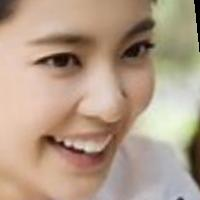

In [43]:
img_path = f'D:/03.cnn-20250714T013117Z-1-001/03.cnn/UTKFace/{file_name}'
image = load_img(img_path,target_size=(200,200))
image


In [44]:
image=img_to_array(image)
image

array([[[ 54.,  48.,  48.],
        [ 54.,  48.,  48.],
        [ 57.,  49.,  47.],
        ...,
        [ 12.,   7.,  13.],
        [  1.,   0.,   7.],
        [  4.,   1.,  10.]],

       [[ 55.,  49.,  49.],
        [ 55.,  49.,  49.],
        [ 58.,  50.,  48.],
        ...,
        [  3.,   0.,   4.],
        [  1.,   0.,   5.],
        [  8.,   5.,  14.]],

       [[ 58.,  50.,  48.],
        [ 58.,  50.,  48.],
        [ 59.,  49.,  48.],
        ...,
        [  3.,   0.,   4.],
        [  1.,   0.,   5.],
        [  1.,   0.,   5.]],

       ...,

       [[204., 164., 129.],
        [204., 164., 129.],
        [205., 165., 130.],
        ...,
        [180., 180., 188.],
        [182., 179., 188.],
        [183., 180., 189.]],

       [[203., 163., 128.],
        [203., 163., 128.],
        [203., 163., 128.],
        ...,
        [179., 179., 189.],
        [180., 177., 188.],
        [180., 177., 188.]],

       [[202., 162., 127.],
        [202., 162., 127.],
        [203., 1

In [46]:
image = np.expand_dims(image,axis=0)
image.shape

(1, 200, 200, 3)

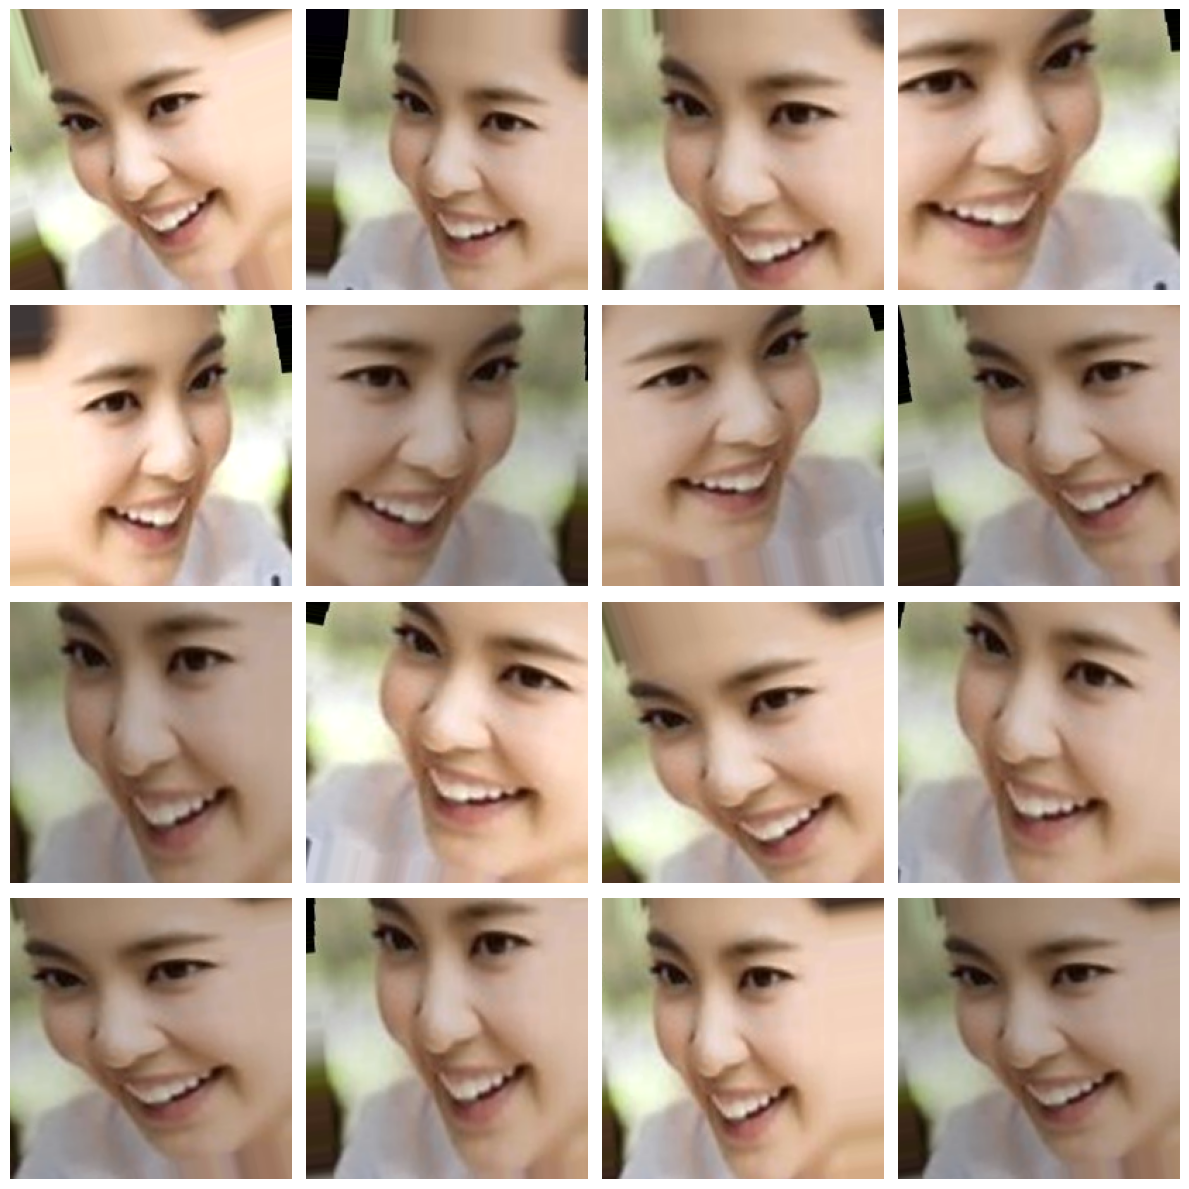

In [47]:
#사진을 다양한 각도,밝기,방향으로 돌려봅니다. 
aug_iter = train_datagen.flow(image,batch_size=1)
plt.figure(figsize=(12, 12))
for i in range(16):
    plt.subplot(4,4,i+1)
    aug_image=next(aug_iter)[0]
    plt.imshow(aug_image)
    plt.axis('off')
plt.tight_layout()

In [50]:
test_datagen = ImageDataGenerator(rescale=1./255)
batch_size=32
image_size=(200,200)

In [51]:
train_generator= train_datagen.flow_from_dataframe(
    df_train,
    directory=img_dir,
    x_col='filename',
    y_col='age',
    target_size=image_size,
    batch_size=batch_size,
    class_mode='raw',
    shuffle=True
)

Found 18966 validated image filenames.


In [52]:
test_generator=test_datagen.flow_from_dataframe(
    df_test,
    directory=img_dir,
    x_col='filename',
    y_col='age',
    target_size=image_size,
    batch_size=batch_size,
    class_mode='raw',
    shuffle=False
)

Found 4742 validated image filenames.


In [57]:
X_batch,y_batch=next(train_generator)
print("이미지배치형태 : ",X_batch.shape)
print("나이 배치 형태 : ",y_batch.shape)
print("첫번째 이미지의 나이:", y_batch[0])

이미지배치형태 :  (32, 200, 200, 3)
나이 배치 형태 :  (32,)
첫번째 이미지의 나이: 42


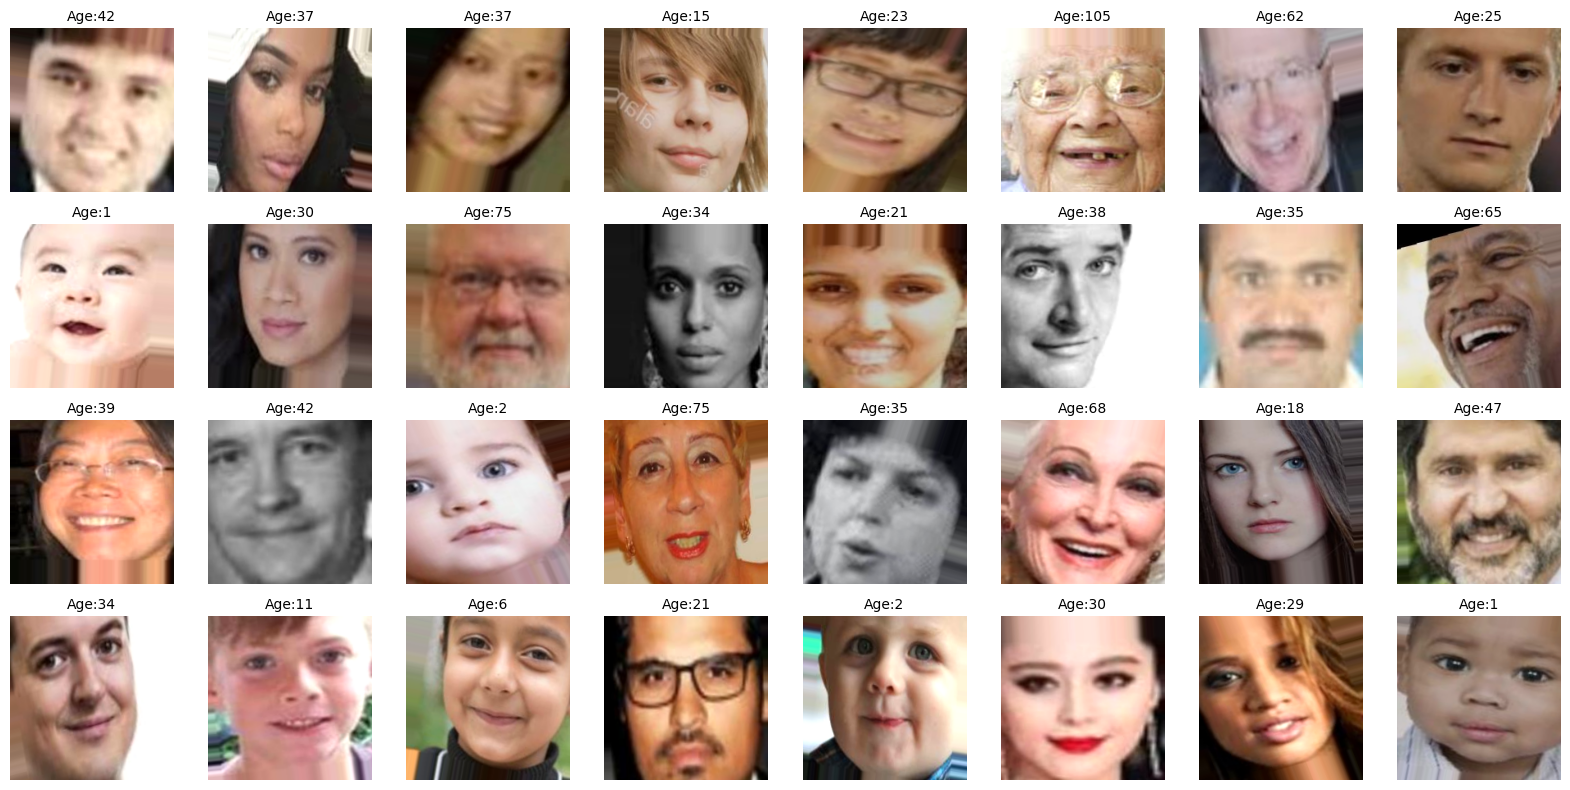

In [61]:
plt.figure(figsize=(16,8))
for i in range(32):
    plt.subplot(4,8,i+1)
    plt.imshow(X_batch[i])
    plt.title(f'Age:{int(y_batch[i])}',fontsize=10)
    plt.axis('off')
plt.tight_layout()
plt.show()

In [63]:
age_model=Sequential([
    Conv2D(64, kernel_size=3,padding='same',input_shape=(200,200,3),kernel_initializer=HeNormal()),
    BatchNormalization(),
    Activation('relu'),
    MaxPool2D(pool_size=3,strides=2),
    SpatialDropout2D(0.1),
    
    Conv2D(128,kernel_size=3,padding='same',kernel_initializer=HeNormal()),
    BatchNormalization(),
    Activation('relu'),
    MaxPool2D(pool_size=3,strides=2),
    SpatialDropout2D(0.1),

    Conv2D(256,kernel_size=3,padding='same',kernel_initializer=HeNormal()),
    BatchNormalization(),
    Activation('relu'),
    MaxPool2D(pool_size=3,strides=2),
    SpatialDropout2D(0.1),

    Conv2D(512,kernel_size=3,padding='same',kernel_initializer=HeNormal()),
    BatchNormalization(),
    Activation('relu'),
    MaxPool2D(pool_size=3,strides=2),
    SpatialDropout2D(0.1),
    
    GlobalAveragePooling2D(),
    Dense(128,kernel_initializer=HeNormal()),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.25),
    Dense(1,activation='linear',name='age')
])

In [64]:
age_model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_4 (Conv2D)           (None, 200, 200, 64)      1792      
                                                                 
 batch_normalization_4 (Batc  (None, 200, 200, 64)     256       
 hNormalization)                                                 
                                                                 
 activation_4 (Activation)   (None, 200, 200, 64)      0         
                                                                 
 max_pooling2d_4 (MaxPooling  (None, 99, 99, 64)       0         
 2D)                                                             
                                                                 
 spatial_dropout2d_4 (Spatia  (None, 99, 99, 64)       0         
 lDropout2D)                                                     
                                                      

In [65]:
optimizer=Adam(learning_rate=0.01)

In [66]:
callbacks=[
    EarlyStopping(monitor='val_loss',patience=30,restore_best_weights=True,verbose=1),
    ReduceLROnPlateau(monitor='val_loss',factor=0.9,patience=10,verbose=1,min_lr=1e-6),
    ModelCheckpoint('best_age_model_final.h5',monitor='val_loss',save_best_only=True,verbose=1)
]

In [67]:
age_model.compile(
    optimizer=optimizer,
    loss='mse',
    metrics=['mae']
)

In [ ]:
history = age_model.fit(
    train_generator,
    epochs=20,
    validation_data=test_generator,
    callbacks=callbacks
)

Epoch 1/20
 50/593 [=>............................] - ETA: 11:55 - loss: 802.9346 - mae: 22.4259